# 03 Feature Engineering RESET
Creates rolling, lag, pressure-difference and rate-of-change features from `metropt3_cleaned.csv`.



In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print('Python:', sys.executable)
print('pandas:', pd.__version__)



Python: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\.venv\Scripts\python.exe
pandas: 2.2.2


In [3]:
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_TABLES_DIR = PROJECT_ROOT / 'outputs' / 'tables'
OUTPUT_FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
for p in [PROCESSED_DATA_DIR, OUTPUT_TABLES_DIR, OUTPUT_FIGURES_DIR]: p.mkdir(parents=True, exist_ok=True)
cleaned_path = PROCESSED_DATA_DIR / 'metropt3_cleaned.csv'
features_path = PROCESSED_DATA_DIR / 'metropt3_features.csv'



In [4]:
if not cleaned_path.exists(): raise FileNotFoundError('Run Step 2 first.')
df = pd.read_csv(cleaned_path)
timestamp_col = 'timestamp' if 'timestamp' in df.columns else [c for c in ['Timestamp','time','Time','datetime','Datetime'] if c in df.columns][0]
df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')
df = df.dropna(subset=[timestamp_col]).sort_values(timestamp_col).reset_index(drop=True)
if df[timestamp_col].max() < pd.Timestamp('2020-07-01'):
    raise ValueError('Cleaned dataset is partial. Rerun Step 2.')
sensors = [c for c in ['TP2','TP3','H1','DV_pressure','Reservoirs','Oil_temperature','Motor_current','Caudal_impulses'] if c in df.columns]
for c in sensors: df[c] = pd.to_numeric(df[c], errors='coerce').astype('float32')
print('Input shape:', df.shape)
print('End:', df[timestamp_col].max())
print('Sensors:', sensors)



Input shape: (1516948, 17)
End: 2020-09-01 03:59:50
Sensors: ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'Caudal_impulses']


In [5]:
frames = []
records = []
pressure = {}
if {'TP2','TP3'}.issubset(df.columns): pressure['TP2_TP3_diff'] = df['TP2'] - df['TP3']
if {'Reservoirs','DV_pressure'}.issubset(df.columns): pressure['Reservoirs_DV_pressure_diff'] = df['Reservoirs'] - df['DV_pressure']
if {'TP3','Reservoirs'}.issubset(df.columns): pressure['TP3_Reservoirs_diff'] = df['TP3'] - df['Reservoirs']
if pressure:
    f = pd.DataFrame(pressure).astype('float32'); frames.append(f)
    records += [{'feature_name':c,'feature_type':'pressure_difference'} for c in f.columns]
print('Pressure features:', list(pressure.keys()))



Pressure features: ['TP2_TP3_diff', 'Reservoirs_DV_pressure_diff', 'TP3_Reservoirs_diff']


In [6]:
indexed = df.set_index(timestamp_col)
for sensor in sensors:
    for window in ['15min','60min']:
        r = indexed[sensor].rolling(window=window, min_periods=1)
        f = pd.DataFrame({
            f'{sensor}_roll_mean_{window}': r.mean().astype('float32').values,
            f'{sensor}_roll_std_{window}': r.std().astype('float32').values,
            f'{sensor}_roll_min_{window}': r.min().astype('float32').values,
            f'{sensor}_roll_max_{window}': r.max().astype('float32').values,
        })
        frames.append(f)
        records += [{'feature_name':c,'feature_type':'rolling_window'} for c in f.columns]
print('Rolling features created')



Rolling features created


In [7]:
def lag_frame(data, timestamp_column, sensor_cols, lag_minutes):
    base = data[[timestamp_column]].copy()
    base['row_id'] = np.arange(len(base))
    base['target_lag_time'] = base[timestamp_column] - pd.Timedelta(minutes=lag_minutes)
    base = base.sort_values('target_lag_time')
    lookup = data[[timestamp_column] + sensor_cols].sort_values(timestamp_column)
    matched = pd.merge_asof(base, lookup, left_on='target_lag_time', right_on=timestamp_column, direction='backward')
    matched = matched.sort_values('row_id')
    return pd.DataFrame({f'{s}_lag_{lag_minutes}min': matched[s].astype('float32').values for s in sensor_cols})
for lag in [5,15,60]:
    f = lag_frame(df, timestamp_col, sensors, lag)
    frames.append(f)
    records += [{'feature_name':c,'feature_type':'lag'} for c in f.columns]
    print('Lag created:', lag, f.shape)



Lag created: 5 (1516948, 8)
Lag created: 15 (1516948, 8)
Lag created: 60 (1516948, 8)


In [8]:
df_features = pd.concat([df.reset_index(drop=True)] + frames, axis=1)
rate = {}
for sensor in sensors:
    lag_col = f'{sensor}_lag_5min'
    if lag_col in df_features.columns:
        rate[f'{sensor}_rate_change_5min'] = (df_features[sensor] - df_features[lag_col]).astype('float32')
if rate:
    f = pd.DataFrame(rate); df_features = pd.concat([df_features, f], axis=1)
    records += [{'feature_name':c,'feature_type':'rate_of_change'} for c in f.columns]
print('Final feature shape:', df_features.shape)



Final feature shape: (1516948, 116)


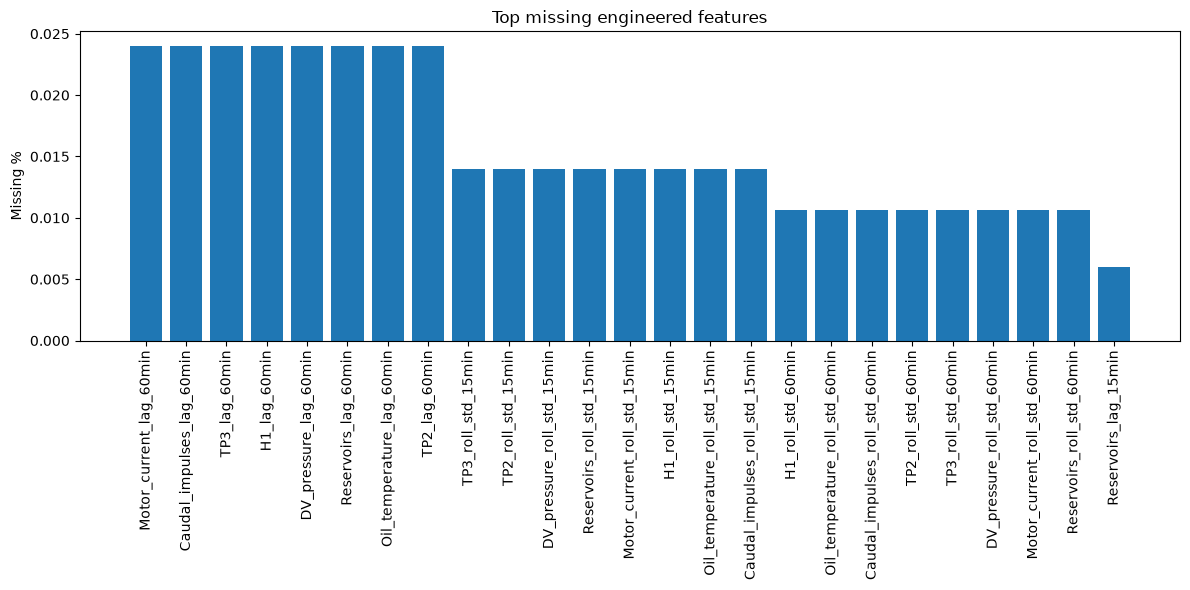

,column,missing_count,missing_percentage
106,Motor_current_lag_60min,364,0.023996
107,Caudal_impulses_lag_60min,364,0.023996
101,TP3_lag_60min,364,0.023996
102,H1_lag_60min,364,0.023996
103,DV_pressure_lag_60min,364,0.023996
104,Reservoirs_lag_60min,364,0.023996
105,Oil_temperature_lag_60min,364,0.023996
100,TP2_lag_60min,364,0.023996
29,TP3_roll_std_15min,212,0.013975
21,TP2_roll_std_15min,212,0.013975


In [9]:
missing = df_features.isna().sum().reset_index()
missing.columns = ['column','missing_count']
missing['missing_percentage'] = missing['missing_count'] / len(df_features) * 100
missing = missing.sort_values('missing_count', ascending=False)
missing.to_csv(OUTPUT_TABLES_DIR / 'features_missing_values.csv', index=False)
top = missing[missing['missing_count'] > 0].head(25)
if not top.empty:
    plt.figure(figsize=(12,6)); plt.bar(top['column'], top['missing_percentage']); plt.xticks(rotation=90); plt.ylabel('Missing %'); plt.title('Top missing engineered features'); plt.tight_layout(); plt.savefig(OUTPUT_FIGURES_DIR/'feature_missing_values.png', dpi=300); plt.show()
missing.head(20)



In [10]:
original_records = [{'feature_name':c,'feature_type':'timestamp' if c==timestamp_col else ('raw_sensor' if c in sensors else 'other_original_or_digital')} for c in df.columns]
pd.DataFrame(original_records + records).to_csv(OUTPUT_TABLES_DIR / 'feature_list.csv', index=False)
summary = pd.DataFrame({'item':['Input rows','Input columns','Output rows','Output columns','New columns added','Sensors','Total missing values'], 'value':[df.shape[0],df.shape[1],df_features.shape[0],df_features.shape[1],df_features.shape[1]-df.shape[1],', '.join(sensors),int(df_features.isna().sum().sum())]})
summary.to_csv(OUTPUT_TABLES_DIR / 'feature_engineering_summary.csv', index=False)
df_features.to_csv(features_path, index=False)
print('Saved:', features_path)
summary


Saved: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\metropt3_features.csv


,item,value
0,Input rows,1516948
1,Input columns,17
2,Output rows,1516948
3,Output columns,116
4,New columns added,99
5,Sensors,"TP2, TP3, H1, DV_pressure, Reservoirs, Oil_tem..."
6,Total missing values,7120
